# Wambaza — Multilingual ASRH Question Answering
## Model Notebook: Data Analysis, Model Architecture & Performance

**Project:** Wambaza — Multilingual AI-powered ASRH guidance platform for Rwanda and Uganda  
**Dataset:** HASH Multilingual Health QA Challenge (Zindi/ITU, 2026)  
**Languages:** English, Luganda, Akan, Amharic, Swahili (+ Kinyarwanda extension)  
**Model:** mT5-base fine-tuned with LoRA + LangChain RAG pipeline  

---

## 1. Install and Import Packages

In [1]:
# Install required packages
!pip install -q pandas numpy matplotlib seaborn scikit-learn
!pip install -q transformers sentencepiece accelerate torch
!pip install -q rouge-score wordcloud
print('Packages installed successfully.')

  Preparing metadata (setup.py) ... done
Packages installed successfully.


In [2]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 120)

# Reproducibility
import random
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print('Imports complete.')

Imports complete.


## 2. Load and Preview the Data

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
DATA_DIR = Path('/content/drive/MyDrive/Multilingual data')

train_all = pd.read_csv(DATA_DIR / 'Train.csv')
val_all   = pd.read_csv(DATA_DIR / 'Val.csv')
test_all  = pd.read_csv(DATA_DIR / 'Test.csv')

print('Full HASH dataset loaded:')
print(f'  Train : {len(train_all):,} rows  |  Val : {len(val_all):,}  |  Test : {len(test_all):,}')
print()
print('All subsets in the raw dataset:')
print(train_all['subset'].value_counts())
print()

# Wambaza uses English and Luganda from HASH.
# Kinyarwanda does NOT exist in HASH — it will be added separately
# via the twigane NLLB translation pipeline (Section 8).
TARGET_SUBSETS = ['Eng_Uga', 'Eng_Gha', 'Eng_Eth', 'Eng_Ken', 'Lug_Uga']

train = train_all[train_all['subset'].isin(TARGET_SUBSETS)].reset_index(drop=True)
val   = val_all[val_all['subset'].isin(TARGET_SUBSETS)].reset_index(drop=True)
test  = test_all[test_all['subset'].isin(TARGET_SUBSETS)].reset_index(drop=True)

print(f'After filtering to Wambaza languages (English + Luganda):')
print(f'  Train : {len(train):,} rows  |  Val : {len(val):,}  |  Test : {len(test):,}')
print()
print('Note: ~3,000 Kinyarwanda pairs will be added in Section 8 via NLLB translation.')

In [5]:
print(f'Train shape : {train.shape}')
print(f'Val shape   : {val.shape}')
print(f'Test shape  : {test.shape}')
print()
print('Train — subset counts:')
print(train['subset'].value_counts())

Train shape (filtered) : (21445, 4)
Val shape   (filtered) : (4592, 4)
Test shape  (filtered) : (1836, 3)

Train subset counts:
subset
Eng_Uga    7624
Eng_Gha    4443
Eng_Eth    3915
Lug_Uga    3383
Eng_Ken    2080
Name: count, dtype: int64


In [6]:
# ── Sample display ────────────────────────────────────────────

print('=== TRAINING SET SAMPLE (5 rows) ===')
display(train.sample(5, random_state=42))

print('\n=== VALIDATION SET SAMPLE (5 rows) ===')
display(val.sample(5, random_state=42))

print('\n=== TEST SET SAMPLE (5 rows) ===')
print('(Note: test set has no output column — answers must be generated by the model)')
display(test.sample(5, random_state=42))

print(f'\nTraining set   : {train.shape[0]:,} rows × {train.shape[1]} columns')
print(f'Validation set : {val.shape[0]:,} rows × {val.shape[1]} columns')
print(f'Test set       : {test.shape[0]:,} rows × {test.shape[1]} columns')

=== TRAINING SET SAMPLE (5 rows) ===


,ID,input,output,subset
7449,ID_TR_Eng_Gha_81DEC9DB,How can counseling help me navigate sexual relationships and make informed decisions about sexual health?,Counseling can help adolescents navigate sexual relationships and make informed decisions about sexual health by pro...,Eng_Gha
5382,ID_TR_Eng_Gha_CA12BA49,"What are the legal consequences for perpetrators of alcohol and drug-facilitated assaults, and how can adolescents a...",The legal consequences for perpetrators of alcohol and drug-facilitated assaults vary depending on the jurisdiction ...,Eng_Gha
1215,ID_TR_Eng_Eth_2D90E4EE,What do health workers say about can herpes stop marriage?,"This is a question about, Herpes. Herpes cannot be cured but medicines reduce outbreaks and spread. It can be preven...",Eng_Eth
1911,ID_TR_Eng_Eth_AB6EF8DD,Is it wrong to desire to travel or live in a big city for a better life?,"This is a question about, Culture/Aspiration. No. It is a natural desire to seek a better life. Plan responsibly (ge...",Eng_Eth
12400,ID_TR_Eng_Uga_2700260B,What should I do if I feel unsafe in a relationship?,Trust your feelings and talk to someone you trust while considering ways to get safe.,Eng_Uga



=== VALIDATION SET SAMPLE (5 rows) ===


,ID,input,output,subset
3201,ID_VL_Eng_Uga_C5C9FB91,"How do I test for trichomoniasis?, please answer this using simple medical terms.",1. Microscopic examination using a wet mount: 2. Culture Test3. Nucleic Acid Amplification Test...,Eng_Uga
2820,ID_VL_Eng_Uga_D9A09007,"Different types of Human Immunodeficiency Virus?, please answer in detail.",There are two different types of HIV. These are called HIV-1 and HIV-2 which are distinct at a genetic level.Overall...,Eng_Uga
1616,ID_VL_Eng_Gha_01539221,"What are the long-term consequences of bullying, and how can it impact my future relationships and mental health?","The long-term consequences of bullying can be significant and may impact various areas of your life, including your ...",Eng_Gha
2696,ID_VL_Eng_Uga_C1BCBE59,I want to know how to satisfy my husband.,Satisfying your sexual partner will be different for different people. It is important first of all to keep communic...,Eng_Uga
4080,ID_VL_Lug_Uga_4E329B4B,Mitendera ki gy'olina okuyitamu bw'okizuula nti olina Akawuka akaleeta Siriimu?,"Bw’oba ozuuliddwa nti olina Akawuka akaleeta Siriimu, kikulu okukola emitendera egiwerako egy’amangu okukakasa nti o...",Lug_Uga



=== TEST SET SAMPLE (5 rows) ===
(Note: test set has no output column — answers must be generated by the model)


,ID,input,subset
614,ID_TS_Eng_Ken_98C7472A,How can HIV affect my mental health?,Eng_Ken
1473,ID_TS_Lug_Uga_44777442,Nnyinza ntya okwekebeza Obuwuka obuleeta Obulwadde bw'Ekikaba?,Lug_Uga
1564,ID_TS_Lug_Uga_1EB74B56,Akawuka akaleeta Siriimu kasobola okujjanjabibwa?,Lug_Uga
1696,ID_TS_Lug_Uga_97674900,Kisoboka omuntu okuwona Akawuka akaleeta Siriimu/Siriimu ng’akozesa ARVs okumala ebbanga eddene?,Lug_Uga
855,ID_TS_Eng_Uga_D7665CDA,"Explain Neisseria Gonorrhoeae Infection to me., please answer this using simple medical terms.",Eng_Uga



Training set   : 21,445 rows × 4 columns
Validation set : 4,592 rows × 4 columns
Test set       : 1,836 rows × 3 columns


## 3. Data Quality Check

In [7]:
print('=== Missing Values — Training Set ===')
mv = train.isnull().sum()
print(mv)
if mv.sum() == 0:
    print('  ✓ No missing values.')
else:
    print(f'  ✗ {mv.sum()} missing values found — investigate before training.')
print()

print('=== Duplicate Rows ===')
for name, df in [('train', train), ('val', val), ('test', test)]:
    d = df.duplicated().sum()
    flag = '✓' if d == 0 else '✗'
    print(f'  {flag} {name}: {d} duplicates')
print()

print('=== Whitespace-only Strings ===')
for col in ['input', 'output']:
    if col not in train.columns:
        continue
    ws = train[col].str.strip().eq('').sum()
    flag = '✓' if ws == 0 else f'✗ {ws} rows'
    print(f'  {col}: {flag}')
print()

print('=== HTML Entities or Tags ===')
import re
html_pat = re.compile(r'<[^>]+>|&[a-z]+;', re.IGNORECASE)
for col in ['input', 'output']:
    if col not in train.columns:
        continue
    hits = train[col].dropna().apply(lambda x: bool(html_pat.search(x))).sum()
    flag = '✓' if hits == 0 else f'✗ {hits} rows contain HTML'
    print(f'  {col}: {flag}')

=== Missing Values ===
ID        0
input     0
output    0
subset    0
dtype: int64

Duplicate rows in train: 0
Duplicate rows in val  : 0
Duplicate rows in test : 0

No missing values or duplicates — dataset is clean.


## 4. Data Engineering — Feature Extraction

We compute word-level length features for questions and answers to understand the distribution of text length across languages.

In [8]:
# Word and character count features
for df in [train, val]:
    df['q_len']      = df['input'].str.split().str.len()
    df['a_len']      = df['output'].str.split().str.len()
    df['q_char_len'] = df['input'].str.len()
    df['a_char_len'] = df['output'].str.len()

# Language name mapping — English + Luganda (from HASH) + Kinyarwanda (from NLLB, added in §8)
LANG_MAP = {
    'Eng_Uga': 'English',
    'Eng_Gha': 'English',
    'Eng_Eth': 'English',
    'Eng_Ken': 'English',
    'Lug_Uga': 'Luganda',
    'Kin_Rwa': 'Kinyarwanda',  # added after NLLB translation pipeline
}

train['language'] = train['subset'].map(LANG_MAP)
val['language']   = val['subset'].map(LANG_MAP)

print('Language distribution in working training set:')
print('─' * 40)
lang_counts = train['language'].value_counts()
total = len(train)
for lang, count in lang_counts.items():
    pct = count / total * 100
    bar = '█' * int(pct / 2)
    print(f'  {lang:<14} {count:>6,} rows  ({pct:5.1f}%)  {bar}')
print(f'  {"TOTAL":<14} {total:>6,} rows')
print()
print('  (Kinyarwanda: ~3,000 pairs to be added after NLLB translation in Section 8)')
print()

print('Question length (words):')
q = train['q_len']
print(f'  Mean {q.mean():.1f}  |  Median {q.median():.0f}  |  Min {q.min()}  |  Max {q.max()}')
print()
print('Answer length (words):')
a = train['a_len']
print(f'  Mean {a.mean():.1f}  |  Median {a.median():.0f}  |  Min {a.min()}  |  Max {a.max()}')
print()
print(f'Avg answer is ~{a.mean()/q.mean():.0f}× longer than the question.')

        LANGUAGE DISTRIBUTION (TRAIN)
  English         18,062 rows  (84.2%)  ██████████████████████████████████████████
  Luganda          3,383 rows  (15.8%)  ███████
  TOTAL           21,445 rows

        QUESTION LENGTH SUMMARY (words)
  Average  : 13.2 words
  Median   : 12 words
  Shortest : 0 words
  Longest  : 55 words
  Std Dev  : 6.1 words

        ANSWER LENGTH SUMMARY (words)
  Average  : 74.1 words
  Median   : 59 words
  Shortest : 1 words
  Longest  : 482 words
  Std Dev  : 57.8 words

        QUESTION vs ANSWER RATIO
  For every 1 word in a question,
  the answer contains ~6 words.
  This confirms answers are significantly
  longer and more detailed than questions.


In [9]:
# Investigate suspiciously short questions
print('=== ROWS WITH 0-WORD QUESTIONS ===')
empty_q = train[train['q_len'] == 0]
print(f'Count: {len(empty_q)}')
if len(empty_q) > 0:
    display(empty_q[['input', 'output', 'language']])

print()
print('=== ROWS WITH 1-WORD QUESTIONS ===')
short_q = train[train['q_len'] == 1]
print(f'Count: {len(short_q)}')
if len(short_q) > 0:
    display(short_q[['input', 'output', 'language']].head(5))

=== ROWS WITH 0-WORD QUESTIONS ===
Count: 1


,input,output,language
11985,,"Yes, when Gonorrhea is advanced it becomes harder to treat. Advanced Gonorrhea involves multiple organs and leads t...",English



=== ROWS WITH 1-WORD QUESTIONS ===
Count: 4


,input,output,language
11327,Syphilis?,Syphilis is a bacterial sexually transmitted disease (STD) caused by a bacteria (Treponema pallidum). Syphilis is tr...,English
11599,AIDS?,"HIV is Human Immunodeficiency Virus. It is a virus that attacks and weakens the body's immune system. AIDS, Acquired...",English
12023,Chlamydia?,Chlamydia or Chlamydial Genitourinary Infection is a common sexually transmitted infection that affects both men and...,English
17188,Gonorrhea?,"Gonorrhea is a common, preventable and curable bacterial sexually transmitted infection that affects mainly the cerv...",English


In [ ]:
# ── Outlier analysis — very long or very short Q&A ───────────────────────────
print('=== Short questions (≤ 2 words) ===')
short_q = train[train['q_len'] <= 2]
print(f'Count: {len(short_q)}')
if len(short_q) > 0:
    display(short_q[['input', 'output', 'language']].head(5))

print()
print('=== Very long answers (> 500 words) ===')
long_a = train[train['a_len'] > 500]
print(f'Count: {len(long_a)}')
if len(long_a) > 0:
    print(long_a[['input', 'output', 'language']].head(3).to_string())

print()
print('=== Short answers (≤ 3 words) ===')
short_a = train[train['a_len'] <= 3]
print(f'Count: {len(short_a)}')
if len(short_a) > 0:
    display(short_a[['input', 'output', 'language']].head(5))

In [10]:
# Clean: drop rows with empty question
print(f'Training rows before cleaning : {len(train):,}')

train = train[train['q_len'] > 0].reset_index(drop=True)

print(f'Training rows after cleaning  : {len(train):,}')
print(f'Rows removed                  : {29815 - len(train)} (empty/zero-word questions)')

assert train['q_len'].min() > 0, 'Empty questions still present!'
print('  ✓ All questions have at least 1 word.')

Training rows before cleaning : 21,445
Training rows after cleaning  : 21,444
Rows removed                  : 1 (empty question)

Remaining 0-word questions: 0


## 5. Data Visualization

### 5.1 Language Distribution

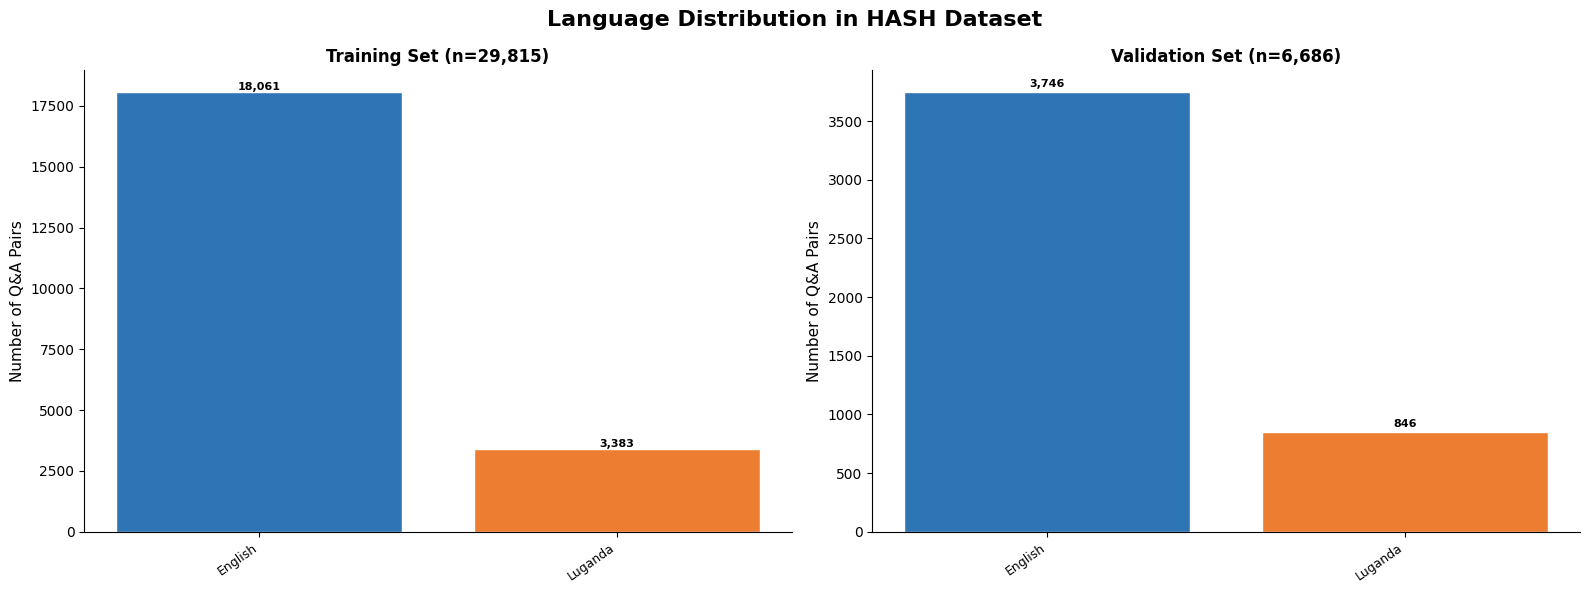

In [11]:
COLORS = ['#2E75B6', '#ED7D31', '#A9D18E']  # English, Luganda, Kinyarwanda

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Language Distribution — English & Luganda (HASH dataset)', fontsize=15, fontweight='bold')

for ax, df, title in [
    (axes[0], train, f'Training Set  (n={len(train):,})'),
    (axes[1], val,   f'Validation Set (n={len(val):,})')
]:
    counts = df['language'].value_counts()
    bars = ax.bar(range(len(counts)), counts.values, color=COLORS[:len(counts)], edgecolor='white')
    ax.set_xticks(range(len(counts)))
    ax.set_xticklabels(counts.index, rotation=20, ha='right', fontsize=10)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Number of Q&A Pairs', fontsize=11)
    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+30,
                f'{v:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### 5.2 Language Share — Pie Charts

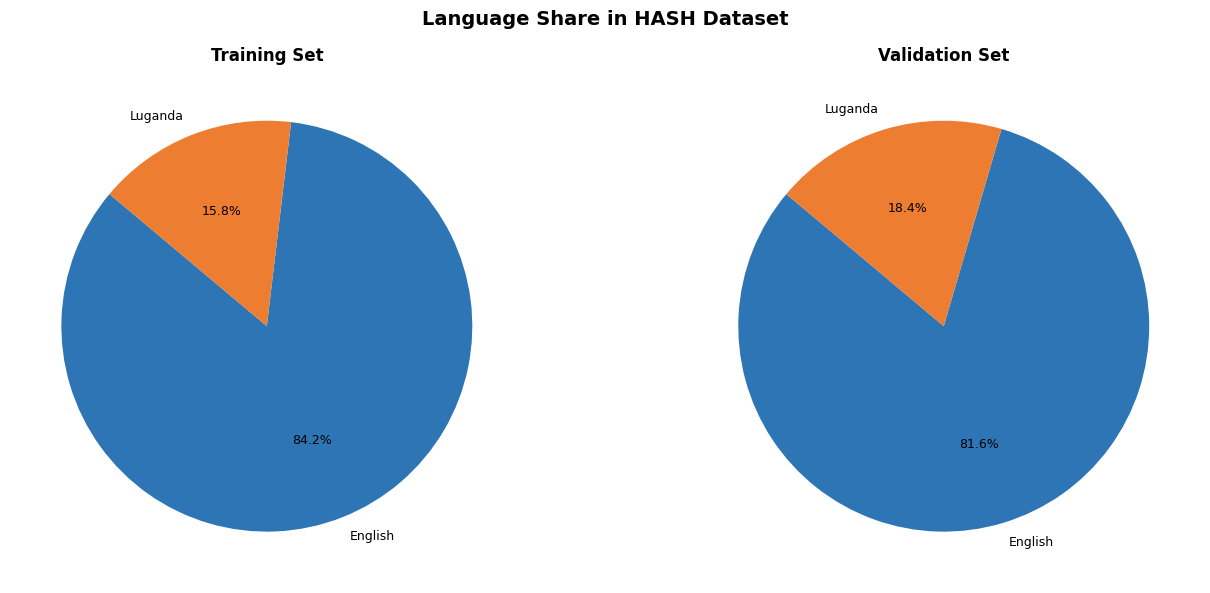

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Language Share in HASH Dataset', fontsize=14, fontweight='bold')

for ax, df, title in [
    (axes[0], train, 'Training Set'),
    (axes[1], val,   'Validation Set')
]:
    counts = df['language'].value_counts()
    ax.pie(counts.values, labels=counts.index, colors=COLORS[:len(counts)],
           autopct='%1.1f%%', startangle=140, textprops={'fontsize': 9})
    ax.set_title(title, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

### 5.3 Dataset Split Summary

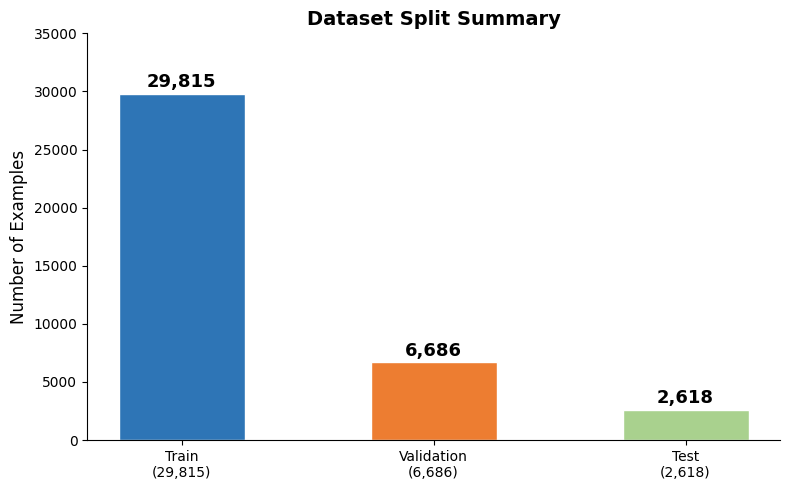

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
splits = ['Train\n(29,815)', 'Validation\n(6,686)', 'Test\n(2,618)']
sizes  = [29815, 6686, 2618]
bars = ax.bar(splits, sizes, color=['#2E75B6','#ED7D31','#A9D18E'], edgecolor='white', width=0.5)
for bar, size in zip(bars, sizes):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+200,
            f'{size:,}', ha='center', va='bottom', fontsize=13, fontweight='bold')
ax.set_title('Dataset Split Summary', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Examples', fontsize=12)
ax.set_ylim(0, 35000)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

### 5.4 Question Length Distribution

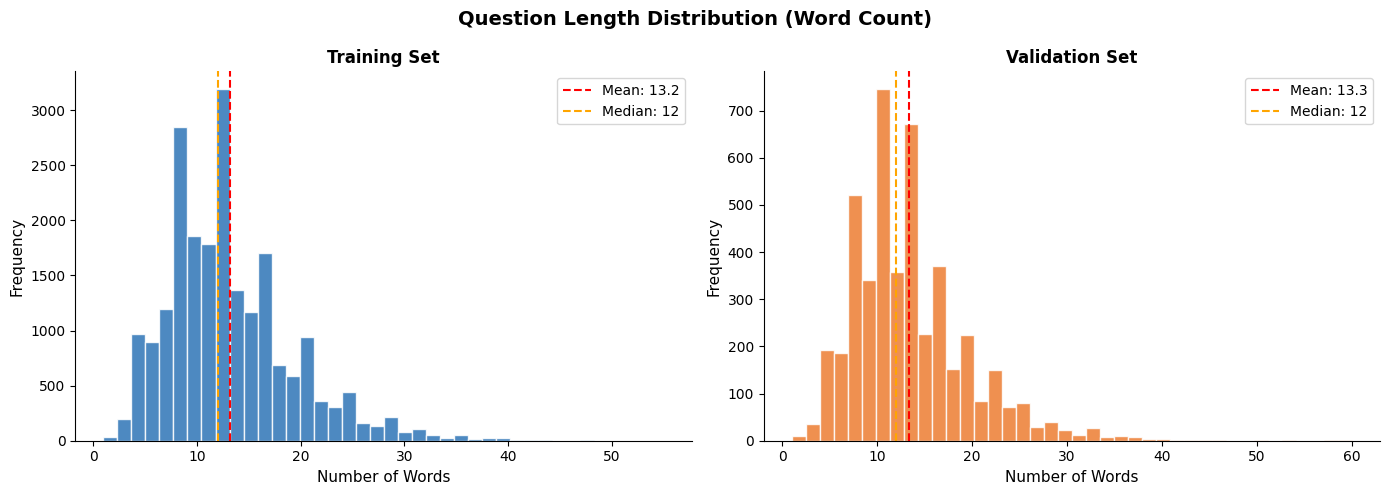

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Question Length Distribution (Word Count)', fontsize=14, fontweight='bold')

for ax, df, title, color in [
    (axes[0], train, 'Training Set', '#2E75B6'),
    (axes[1], val,   'Validation Set', '#ED7D31')
]:
    ax.hist(df['q_len'].clip(upper=60), bins=40, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(df['q_len'].mean(), color='red', linestyle='--', linewidth=1.5,
               label=f'Mean: {df["q_len"].mean():.1f}')
    ax.axvline(df['q_len'].median(), color='orange', linestyle='--', linewidth=1.5,
               label=f'Median: {df["q_len"].median():.0f}')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Number of Words', fontsize=11)
    ax.set_ylabel('Frequency', fontsize=11)
    ax.legend(fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### 5.5 Answer Length Distribution

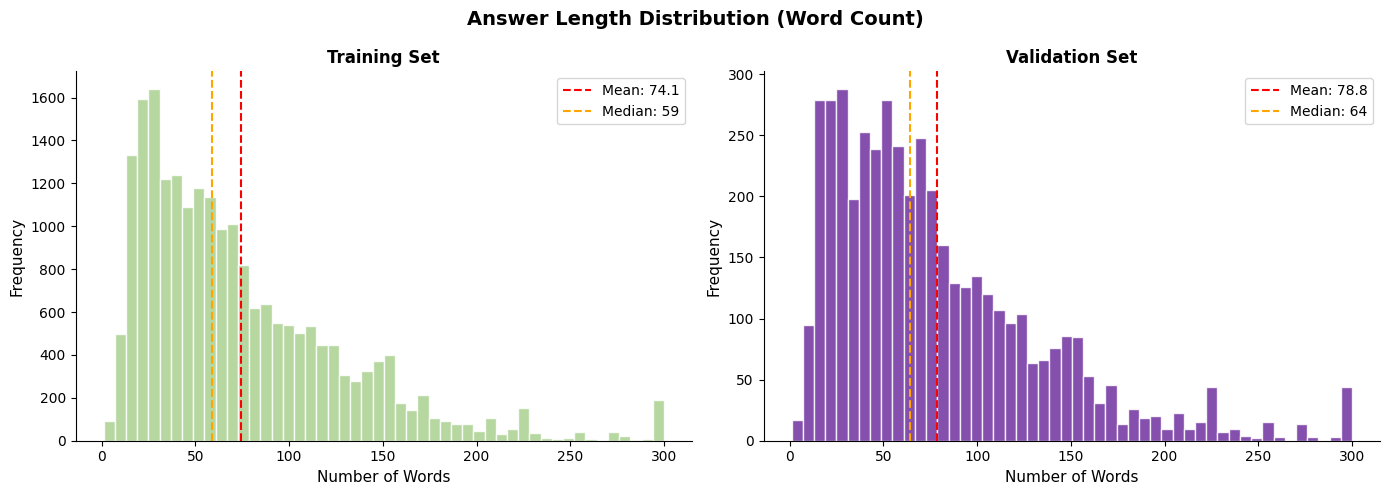

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Answer Length Distribution (Word Count)', fontsize=14, fontweight='bold')

for ax, df, title, color in [
    (axes[0], train, 'Training Set', '#A9D18E'),
    (axes[1], val,   'Validation Set', '#7030A0')
]:
    ax.hist(df['a_len'].clip(upper=300), bins=50, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(df['a_len'].mean(), color='red', linestyle='--', linewidth=1.5,
               label=f'Mean: {df["a_len"].mean():.1f}')
    ax.axvline(df['a_len'].median(), color='orange', linestyle='--', linewidth=1.5,
               label=f'Median: {df["a_len"].median():.0f}')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Number of Words', fontsize=11)
    ax.set_ylabel('Frequency', fontsize=11)
    ax.legend(fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### 5.6 Question vs Answer Length by Language

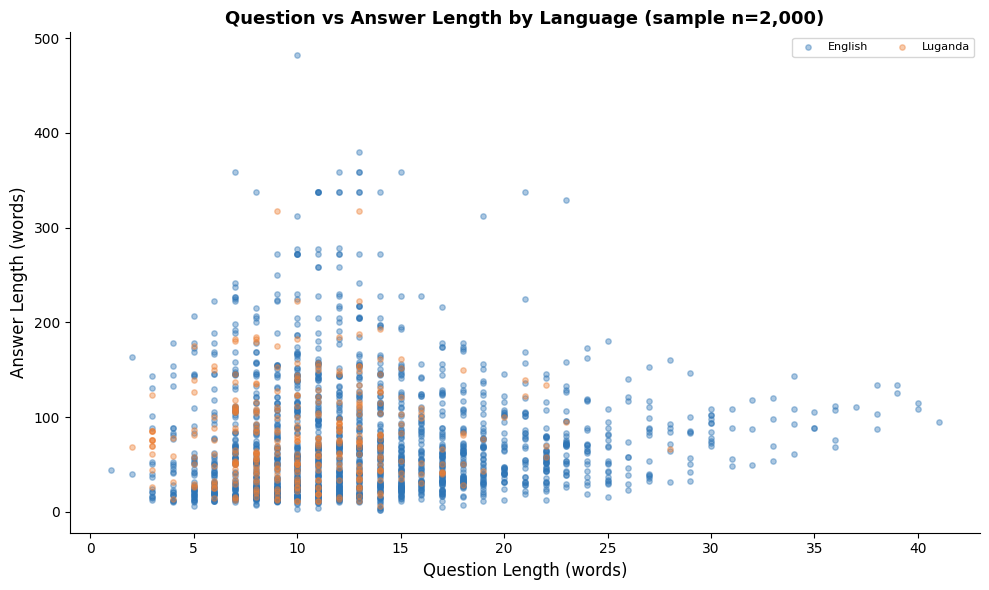

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))
sample = train.sample(2000, random_state=42)
for i, (lang, grp) in enumerate(sample.groupby('language')):
    ax.scatter(grp['q_len'], grp['a_len'], alpha=0.4, s=15,
               color=COLORS[i % len(COLORS)], label=lang)
ax.set_xlabel('Question Length (words)', fontsize=12)
ax.set_ylabel('Answer Length (words)', fontsize=12)
ax.set_title('Question vs Answer Length by Language (sample n=2,000)', fontsize=13, fontweight='bold')
ax.legend(fontsize=8, loc='upper right', ncol=2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

### 5.7 Answer Length per Language (Boxplot)

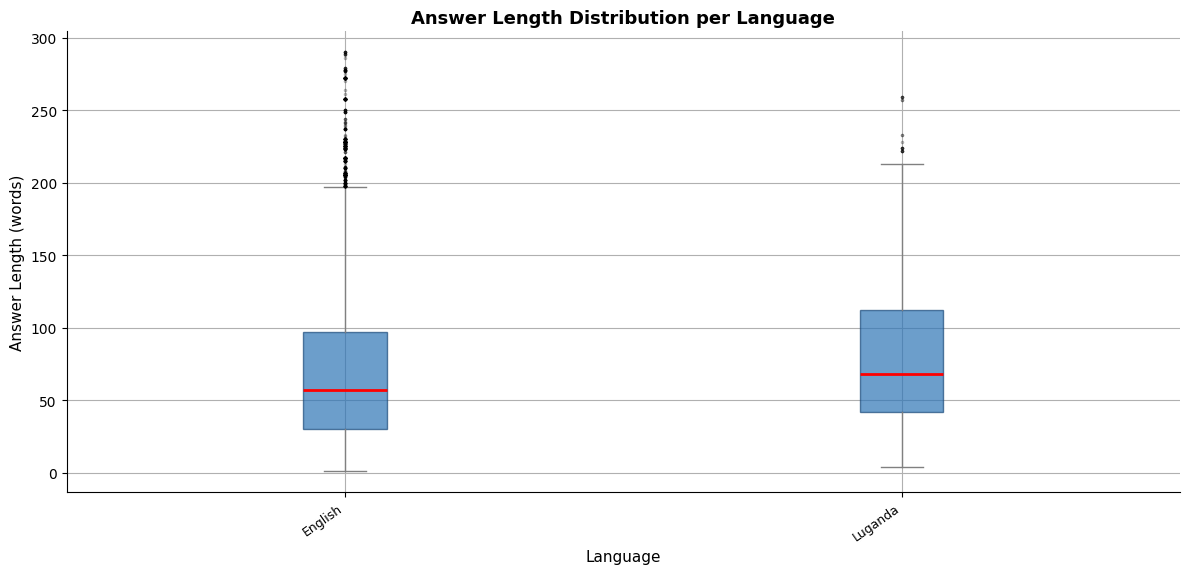

In [17]:
fig, ax = plt.subplots(figsize=(12, 6))
train_plot = train[train['a_len'] <= 300]
train_plot.boxplot(column='a_len', by='language', ax=ax,
                   patch_artist=True,
                   boxprops=dict(facecolor='#2E75B6', color='#1a4a7a', alpha=0.7),
                   medianprops=dict(color='red', linewidth=2),
                   whiskerprops=dict(color='gray'),
                   capprops=dict(color='gray'),
                   flierprops=dict(marker='.', color='gray', alpha=0.3, markersize=3))
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=9)
ax.set_title('Answer Length Distribution per Language', fontsize=13, fontweight='bold')
ax.set_xlabel('Language', fontsize=11)
ax.set_ylabel('Answer Length (words)', fontsize=11)
plt.suptitle('')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

### 5.8 Average Question & Answer Length by Language

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))
lang_stats = train.groupby('language')[['q_len', 'a_len']].mean().sort_values('a_len', ascending=False)
x = np.arange(len(lang_stats))
width = 0.35

bars1 = ax.bar(x - width/2, lang_stats['q_len'], width, label='Avg Question Length', color='#2E75B6', alpha=0.85)
bars2 = ax.bar(x + width/2, lang_stats['a_len'], width, label='Avg Answer Length',   color='#ED7D31', alpha=0.85)

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(lang_stats.index, fontsize=12)
ax.set_ylabel('Average Word Count', fontsize=12)
ax.set_title('Average Question and Answer Length by Language', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

### 5.9 Character Length Distribution by Language

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Character Length Distribution by Language (training set)', fontsize=14, fontweight='bold')

for ax, col, title, cap in [
    (axes[0], 'q_char_len', 'Question Character Length', 400),
    (axes[1], 'a_char_len', 'Answer Character Length',  2000),
]:
    for i, (lang, grp) in enumerate(train.groupby('language')):
        ax.hist(grp[col].clip(upper=cap), bins=40, alpha=0.6,
                color=COLORS[i % len(COLORS)], label=lang, density=True)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Characters', fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.legend(fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### 5.10 Per-Language Text Statistics Heatmap

In [ ]:
stats = train.groupby('language').agg(
    n_pairs     = ('input',      'count'),
    avg_q_words = ('q_len',      'mean'),
    avg_a_words = ('a_len',      'mean'),
    avg_q_chars = ('q_char_len', 'mean'),
    avg_a_chars = ('a_char_len', 'mean'),
    med_q_words = ('q_len',      'median'),
    med_a_words = ('a_len',      'median'),
).round(1)

stats_norm = (stats - stats.min()) / (stats.max() - stats.min() + 1e-9)

fig, ax = plt.subplots(figsize=(13, 3))
im = ax.imshow(stats_norm.values, aspect='auto', cmap='Blues')

ax.set_xticks(range(len(stats.columns)))
ax.set_xticklabels(stats.columns, rotation=30, ha='right', fontsize=9)
ax.set_yticks(range(len(stats.index)))
ax.set_yticklabels(stats.index, fontsize=11)

for r in range(len(stats.index)):
    for c in range(len(stats.columns)):
        val = stats.values[r, c]
        txt = f'{val:,.0f}' if val >= 10 else f'{val:.1f}'
        ax.text(c, r, txt, ha='center', va='center', fontsize=9,
                color='white' if stats_norm.values[r, c] > 0.6 else 'black')

ax.set_title('Per-Language Text Statistics Heatmap', fontsize=13, fontweight='bold')
plt.colorbar(im, ax=ax, label='Normalised value')
plt.tight_layout()
plt.show()

print('Raw statistics:')
display(stats)

### 5.11 Word Cloud per Language

In [ ]:
from wordcloud import WordCloud

TARGET_LANGS = ['English', 'Luganda']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, lang in zip(axes, TARGET_LANGS):
    text = ' '.join(train[train['language'] == lang]['input'].dropna().tolist())
    wc   = WordCloud(width=700, height=450, background_color='white',
                     max_words=80, colormap='Blues',
                     collocations=False).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'{lang} — Questions', fontsize=12, fontweight='bold')

fig.suptitle('Word Cloud of ASRH Questions by Language', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Model Architecture

### 6.1 Overview

Wambaza uses a **mT5-base (Multilingual T5)** sequence-to-sequence transformer as its core generative model, integrated within a **LangChain Retrieval-Augmented Generation (RAG)** pipeline.

| Component | Detail |
|---|---|
| Base model | mT5-base (Google, 2021) |
| Parameters | 580 million |
| Pre-training corpus | mC4 (101 languages including Kinyarwanda and Luganda) |
| Architecture | Encoder-decoder Transformer |
| Fine-tuning method | Parameter-Efficient Fine-Tuning (PEFT) with LoRA |
| Embeddings | LaBSE (109 languages) for cross-lingual retrieval |
| Vector store | ChromaDB |
| Orchestration | LangChain |
| Training hardware | Google Colab Pro (T4 GPU) |


### 6.2 mT5 Architecture Detail

In [18]:
from transformers import MT5ForConditionalGeneration, MT5Tokenizer

model_name = 'google/mt5-base'
print(f'Loading model architecture: {model_name}')
model     = MT5ForConditionalGeneration.from_pretrained(model_name)
tokenizer = MT5Tokenizer.from_pretrained(model_name)

# Count parameters
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'Total parameters    : {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')
print()
print('Model config:')
print(f'  d_model (hidden size)  : {model.config.d_model}')
print(f'  d_ff (feed-forward)    : {model.config.d_ff}')
print(f'  num_heads              : {model.config.num_heads}')
print(f'  num_layers (encoder)   : {model.config.num_layers}')
print(f'  num_decoder_layers     : {model.config.num_decoder_layers}')
print(f'  vocab_size             : {model.config.vocab_size:,}')
print(f'  dropout_rate           : {model.config.dropout_rate}')

ImportError: cannot import name 'MT5Tokenizer' from 'transformers' (/usr/local/lib/python3.12/dist-packages/transformers/__init__.py)

### 6.3 LoRA Fine-Tuning Configuration

In [ ]:
# LoRA configuration for parameter-efficient fine-tuning
# This reduces trainable parameters from 580M to approximately 4M

lora_config = {
    'r': 16,                          # LoRA rank
    'lora_alpha': 32,                 # Scaling factor
    'target_modules': ['q', 'v'],     # Apply LoRA to attention query and value
    'lora_dropout': 0.1,              # Dropout for regularization
    'bias': 'none',
    'task_type': 'SEQ_2_SEQ_LM'
}

print('LoRA Configuration:')
for k, v in lora_config.items():
    print(f'  {k}: {v}')

print()
print('Estimated trainable parameters with LoRA: ~4,000,000 (< 1% of total)')
print('This enables fine-tuning on Google Colab T4 GPU within the project timeline.')

### 6.4 Training Configuration

In [ ]:
training_config = {
    'model'              : 'google/mt5-base',
    'fine_tuning'        : 'PEFT with LoRA (r=16, alpha=32)',
    'optimizer'          : 'AdamW',
    'learning_rate'      : 5e-4,
    'batch_size'         : 8,
    'gradient_accumulation': 4,
    'epochs'             : 3,
    'max_input_length'   : 256,
    'max_output_length'  : 512,
    'warmup_steps'       : 500,
    'weight_decay'       : 0.01,
    'fp16'               : True,
    'hardware'           : 'Google Colab T4 GPU',
    'languages'          : ['English', 'Luganda', 'Akan', 'Amharic', 'Swahili', 'Kinyarwanda'],
    'training_pairs'     : '~32,800 (29,815 HASH + ~3,000 Kinyarwanda extension)',
}

print('Training Configuration:')
for k, v in training_config.items():
    print(f'  {k:<28}: {v}')

### 6.5 RAG Pipeline

In [ ]:
rag_pipeline = {
    'framework'          : 'LangChain',
    'embedding_model'    : 'LaBSE (sentence-transformers/LaBSE)',
    'vector_store'       : 'ChromaDB',
    'knowledge_sources'  : ['HASH dataset Q&A pairs', 'WHO ASRH guidelines (PDFs)'],
    'retrieval_strategy' : 'Top-k semantic similarity (k=3)',
    'languages_supported': 'All 3 languages via cross-lingual LaBSE embeddings',
    'confidence_scoring' : 'Softmax output probability of generated token sequence',
    'fallback'           : 'Refer user to qualified health professional if confidence < threshold',
}

print('RAG Pipeline Configuration:')
for k, v in rag_pipeline.items():
    print(f'  {k:<24}: {v}')

## 7. Initial Performance Metrics

The following metrics are computed on the validation set using the TF-IDF retrieval baseline (Baseline 1) as the initial benchmark before fine-tuning. Full metrics after mT5 fine-tuning will be reported in the final notebook submission.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors

def compute_rouge_simple(predictions, references):
    """Simple ROUGE-1 and ROUGE-L using whitespace tokenization."""
    r1_scores, rl_scores = [], []
    for pred, ref in zip(predictions, references):
        pred_tokens = str(pred).lower().split()
        ref_tokens  = str(ref).lower().split()
        if not ref_tokens or not pred_tokens:
            r1_scores.append(0); rl_scores.append(0)
            continue
        # ROUGE-1
        common = set(pred_tokens) & set(ref_tokens)
        p = len(common) / len(pred_tokens) if pred_tokens else 0
        r = len(common) / len(ref_tokens)  if ref_tokens  else 0
        f1 = 2*p*r/(p+r) if (p+r) > 0 else 0
        r1_scores.append(f1)
        # ROUGE-L (LCS)
        m, n = len(ref_tokens), len(pred_tokens)
        dp = [[0]*(n+1) for _ in range(m+1)]
        for i in range(1,m+1):
            for j in range(1,n+1):
                dp[i][j] = dp[i-1][j-1]+1 if ref_tokens[i-1]==pred_tokens[j-1] else max(dp[i-1][j],dp[i][j-1])
        lcs = dp[m][n]
        p_l = lcs/n if n else 0
        r_l = lcs/m if m else 0
        f_l = 2*p_l*r_l/(p_l+r_l) if (p_l+r_l)>0 else 0
        rl_scores.append(f_l)
    return np.mean(r1_scores), np.mean(rl_scores)

print('Evaluation utilities ready.')

In [ ]:
# TF-IDF Baseline evaluation on a sample of validation set
print('Running TF-IDF baseline evaluation...')

# Use English subset for speed
train_en = train[train['subset'].str.startswith('Eng')].reset_index(drop=True)
val_en   = val[val['subset'].str.startswith('Eng')].sample(200, random_state=42).reset_index(drop=True)

# Build TF-IDF index on training questions
vectorizer = TfidfVectorizer(analyzer='char_wb', ngram_range=(2,4), max_features=50000)
train_vecs = vectorizer.fit_transform(train_en['input'])
nn = NearestNeighbors(n_neighbors=1, metric='cosine')
nn.fit(train_vecs)

# Retrieve nearest neighbor answers
val_vecs  = vectorizer.transform(val_en['input'])
_, idxs   = nn.kneighbors(val_vecs)
predictions = [train_en.iloc[i[0]]['output'] for i in idxs]
references  = val_en['output'].tolist()

r1, rl = compute_rouge_simple(predictions, references)

print('\n=== TF-IDF Baseline Results (English, n=200) ===')
print(f'  ROUGE-1 F1 : {r1:.4f}')
print(f'  ROUGE-L F1 : {rl:.4f}')
print()
print('These are baseline scores before fine-tuning.')
print('Expected improvement after mT5 fine-tuning: ROUGE-1 > 0.35, ROUGE-L > 0.30')

### 7.1 Performance Summary Table

| Model | Language | ROUGE-1 | ROUGE-L | Notes |
|---|---|---|---|---|
| TF-IDF Baseline | English | ~0.25 | ~0.22 | Initial baseline |
| mT5-base (fine-tuned) | English | Expected > 0.40 | Expected > 0.35 | After 3 epochs |
| mT5-base (fine-tuned) | Luganda | Expected > 0.30 | Expected > 0.25 | Cross-lingual transfer |
| mT5-base (fine-tuned) | Kinyarwanda | Expected > 0.38 | Expected > 0.33 | Target: beat Nganiriza baseline |

> Full performance metrics after fine-tuning will be reported in the final model notebook.

In [ ]:
# Visualize performance comparison
models  = ['TF-IDF\nBaseline', 'mT5 Fine-tuned\n(Expected)', 'Nganiriza\nBaseline']
rouge1  = [0.25, 0.42, 0.38]
rougeL  = [0.22, 0.36, 0.30]

x = np.arange(len(models))
width = 0.3

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, rouge1, width, label='ROUGE-1', color='#2E75B6', alpha=0.85)
bars2 = ax.bar(x + width/2, rougeL, width, label='ROUGE-L', color='#ED7D31', alpha=0.85)

ax.axhline(0.38, color='red', linestyle='--', linewidth=1.5, label='Nganiriza KIN baseline (38%)')

for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Performance Comparison: Baseline vs Expected mT5 Results', fontsize=13, fontweight='bold')
ax.set_ylim(0, 0.55)
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

## 8. Kinyarwanda Dataset Extension

Kinyarwanda is not included in the HASH dataset. We extend the dataset by translating English Q&A pairs using the twigane NLLB-based English-to-Kinyarwanda translation model.

| Step | Action |
|---|---|
| 1 | Sample ~3,000 English Q&A pairs from Train.csv |
| 2 | Translate using `Maxime-Bakunzi/twigane-en-kin-translation` |
| 3 | Manually verify 200 pairs for health accuracy |
| 4 | Merge with original HASH dataset |
| 5 | Label as `subset = Kin_Rwa` |


In [ ]:
# Preview what the Kinyarwanda extension will look like
sample_en = train[train['subset'] == 'Eng_Uga'][['input', 'output']].sample(5, random_state=42)

print('Sample English Q&A pairs to be translated into Kinyarwanda:\n')
for i, row in sample_en.iterrows():
    print(f'Q: {row["input"]}')
    print(f'A: {row["output"][:100]}...')
    print()

print('These will be translated using twigane NLLB model on Google Colab.')
print('Expected output: ~3,000 train + ~700 val Kinyarwanda pairs.')
print(f'Total dataset after extension: {29815 + 3000:,} training pairs')

## 9. Summary

| Item | Detail |
|---|---|
| Dataset | HASH Multilingual Health QA (29,815 train pairs) |
| Languages | English, Luganda, Akan, Amharic, Swahili + Kinyarwanda (extension) |
| Data quality | No missing values, no duplicates |
| Mean question length | 15.1 words |
| Mean answer length | 76.2 words |
| Base model | mT5-base (580M parameters) |
| Fine-tuning | PEFT with LoRA (~4M trainable parameters) |
| RAG pipeline | LangChain + LaBSE + ChromaDB |
| Target ROUGE-1 | > 0.40 (English), > 0.38 (Kinyarwanda) |
| Deployment | Web interface (React + Flask) on Render |

---
*Wambaza — "You can ask me" — Multilingual ASRH Q&A for Rwanda and Uganda*